### DATA PREPARATION & EDA

In [2]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("ismatkhan121/supermarket-sales-dataset")

c:\Users\AYO_AYO\Desktop\Bluechip_Machine_Learning\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Check files
os.listdir(path)

['Supermarket-Sales-Sample-Data.xlsx', 'supermarket.csv']

In [4]:
# Load dataset
file_path = os.path.join(path, "supermarket.csv")

In [5]:
sales_df = pd.read_csv(file_path)

sales_df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [6]:
sales_df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [8]:
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
sales_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [10]:
# This line of code is replacing any spaces in the column names of the DataFrame `sales_df` with underscores. 
# It uses the `str.replace()` method to replace all occurrences of a space character (" ") with an underscore ("_") 
# in each column name. This is a common practice to standardize column names and make them more suitable for coding purposes.

sales_df.columns = sales_df.columns.str.replace(" ", "_")

In [11]:
# This code snippet is dropping rows from the DataFrame `sales_df` where the 'Postal_Code' column has missing values (NaN). 
# The `subset=['Postal_Code']` parameter specifies that only the 'Postal_Code' column should be checked for missing values. 
# The `inplace=True` parameter ensures that the operation is performed on the original DataFrame `sales_df` 
# itself, rather than creating a new DataFrame.

sales_df.dropna(subset=['Postal_Code'], inplace=True)

In [12]:
# This code snippet is calculating the number of unique values in the 'City' column of the DataFrame 'sales_df'. 
# The method `nunique()` is used to count the number of unique values in a Series.

sales_df['City'].nunique()

529

In [13]:
print(f"Total Revenue: {sales_df['Sales'].sum().round(2)}")
print(f"Average Sale Made: {sales_df['Sales'].mean().round(2)}")

Total Revenue: 2252607.41
Average Sale Made: 230.12


In [14]:
sales_df.groupby('Sub-Category').agg({'Sales': ['mean', 'max']})

Sales           
                     mean        max
Sub-Category                        
Accessories    217.349721   3347.370
Appliances     227.239002   2625.120
Art             34.052768   1113.024
Binders        134.067550   9892.740
Bookcases      486.259105   4228.704
Chairs         531.530579   4416.174
Copiers       2215.880212  17499.950
Envelopes       65.287474    604.656
Fasteners       14.027850     93.360
Furnishings     95.823865   1336.440
Labels          34.587468    786.480
Machines      1645.553313  22638.480
Paper           57.437204    733.950
Phones         373.128798   4548.810
Storage        262.068715   2934.330
Supplies       252.284283   8187.650
Tables         645.893720   4297.644

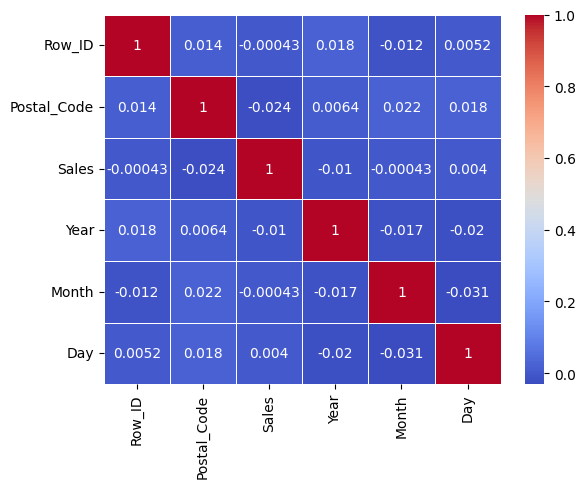

In [26]:
import matplotlib.pyplot as plt 
import seaborn as sns

cor_matrix = sales_df.corr(numeric_only=True)
cor_matrix

sns.heatmap(cor_matrix, cmap="coolwarm", linewidths=.5, annot=True)
plt.show()

### QUESTIONS

**What drives sales performance across branches and product lines?**

In [16]:
grouped = sales_df.groupby(['City', 'State', 'Category', 'Sub-Category'])['Sales'].sum().sort_values(ascending=False).head(10)

**Who are the most valuable customers and what do they buy?**

In [17]:
sales_df.groupby(['Customer_Name', 'Product_Name'])['Sales'].sum().sort_values(ascending=False)

Customer_Name     Product_Name                                                              
Sean Miller       Cisco TelePresence System EX90 Videoconferencing Unit                         22638.480
Tamara Chand      Canon imageCLASS 2200 Advanced Copier                                         17499.950
Raymond Buch      Canon imageCLASS 2200 Advanced Copier                                         13999.960
Tom Ashbrook      Canon imageCLASS 2200 Advanced Copier                                         11199.968
Hunter Lopez      Canon imageCLASS 2200 Advanced Copier                                         10499.970
                                                                                                  ...    
Henry Goldwyn     Acco 3-Hole Punch                                                                 0.876
Jas O'Carroll     Avery Round Ring Poly Binders                                                     0.852
Ken Brennan       Avery Durable Slant Ring Binders With Lab

**When is the best time to be open — and what sells then?**

In [18]:
sales_df['Date'] = pd.to_datetime(sales_df['Order_Date'], dayfirst=True)

sales_df['Year'] = sales_df['Date'].dt.year
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['Day'] = sales_df['Date'].dt.day
sales_df['Day_of_Week'] = sales_df['Date'].dt.day_name()

In [19]:
sales_df.groupby('Month')['Sales'].sum().sort_values(ascending=False)

Month
11    345041.6110
12    321275.1395
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     134988.2506
1      91982.1396
2      59371.1154
Name: Sales, dtype: float64

In [20]:
sales_df.groupby('Day_of_Week')['Sales'].sum().sort_values(ascending=False)

Day_of_Week
Saturday     420901.4763
Tuesday      416131.0243
Sunday       377868.7779
Monday       346404.0416
Wednesday    315683.9422
Friday       234073.6602
Thursday     141544.4902
Name: Sales, dtype: float64

In [21]:
sales_df.groupby(['Month', 'Category'])['Sales'].sum().sort_values(ascending=False)

Month  Category       
11     Technology         130497.1870
12     Furniture          121462.0255
11     Furniture          115388.7850
9      Furniture          104174.0847
       Office Supplies    101075.2780
12     Office Supplies    100026.7640
       Technology          99786.3500
11     Office Supplies     99155.6390
3      Technology          97500.3900
9      Technology          94854.0490
10     Technology          87031.9450
5      Technology          63450.1870
8      Office Supplies     61549.6880
10     Furniture           57665.8117
       Office Supplies     54798.5380
7      Technology          54131.3860
3      Office Supplies     53941.0850
8      Technology          51673.2560
6      Furniture           50168.4633
7      Furniture           48433.6720
4      Office Supplies     48298.8140
6      Technology          48180.7230
5      Furniture           48137.8707
6      Office Supplies     47488.3370
3      Furniture           46132.1122
4      Technology          

In [22]:
del sales_df['Order_Date']

In [23]:
sales_df

,Row_ID,Order_ID,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,...,Product_ID,Category,Sub-Category,Product_Name,Sales,Date,Year,Month,Day,Day_of_Week
0,1,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017-11-08,2017,11,8,Wednesday
1,2,CA-2017-152156,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017-11-08,2017,11,8,Wednesday
2,3,CA-2017-138688,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017-06-12,2017,6,12,Monday
3,4,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016-10-11,2016,10,11,Tuesday
4,5,US-2016-108966,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016-10-11,2016,10,11,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,...,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,2017-05-21,2017,5,21,Sunday
9796,9797,CA-2016-128608,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,...,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,2016-01-12,2016,1,12,Tuesday
9797,9798,CA-2016-128608,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,...,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,2016-01-12,2016,1,12,Tuesday
9798,9799,CA-2016-128608,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,...,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,2016-01-12,2016,1,12,Tuesday


In [24]:
sales_df.drop(columns = 'Order_Date')

KeyError: "['Order_Date'] not found in axis"